# DATA 602 Team 5: Airline Passenger Satisfaction Exploratory Data Analysis (EDA)
**Group Members:**
- Brett Allen
- Eeshani Gundi
- Sruthi Kapudasi
- Bharath Prabhakaran
- Nandhu Unnikrishnan

**Due Date:** 10/26/2024

## Setup

In [1]:
!python -m pip install -q scikit-learn

### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Any
import warnings
from sklearn.preprocessing import FunctionTransformer, QuantileTransformer

### Configurations

In [3]:
sns.set_style('darkgrid')

In [4]:
warnings.filterwarnings('ignore')

## Load and Clean Raw Data

In [5]:
df = pd.read_csv("../datasets/raw/train.csv")

In [6]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [7]:
df.columns

Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

### Remove Unnecessary Columns: Unnamed: 0 , 'id' columns are not necessary for analysis.

In [8]:
df = df.drop(columns=['Unnamed: 0','id'])

In [9]:
df.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

### Formatting Column Names

In [10]:
# Function to convert column names to uppercase and snake_case
df.columns = df.columns.str.upper().str.replace(' ', '_').str.replace('/', '_')

# Display the updated column names
print(df.columns)

Index(['GENDER', 'CUSTOMER_TYPE', 'AGE', 'TYPE_OF_TRAVEL', 'CLASS',
       'FLIGHT_DISTANCE', 'INFLIGHT_WIFI_SERVICE',
       'DEPARTURE_ARRIVAL_TIME_CONVENIENT', 'EASE_OF_ONLINE_BOOKING',
       'GATE_LOCATION', 'FOOD_AND_DRINK', 'ONLINE_BOARDING', 'SEAT_COMFORT',
       'INFLIGHT_ENTERTAINMENT', 'ON-BOARD_SERVICE', 'LEG_ROOM_SERVICE',
       'BAGGAGE_HANDLING', 'CHECKIN_SERVICE', 'INFLIGHT_SERVICE',
       'CLEANLINESS', 'DEPARTURE_DELAY_IN_MINUTES', 'ARRIVAL_DELAY_IN_MINUTES',
       'SATISFACTION'],
      dtype='object')


### Formatting row values

In [11]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Unique values in '{column}': {unique_values}\n")

# Update 'CUSTOMER_TYPE'
df['CUSTOMER_TYPE'] = df['CUSTOMER_TYPE'].replace({
    'disloyal Customer': 'Disloyal',
    'Loyal Customer': 'Loyal'
})

# Update 'TYPE_OF_TRAVEL'
df['TYPE_OF_TRAVEL'] = df['TYPE_OF_TRAVEL'].replace({
    'Personal Travel': 'Personal',
    'Business travel': 'Business'
})

# Update 'SATISFACTION'
df['SATISFACTION'] = df['SATISFACTION'].replace({
    'satisfied': 'Satisfied',
    'neutral or dissatisfied': 'Neutral or Dissatisfied'
})

Unique values in 'GENDER': ['Male' 'Female']

Unique values in 'CUSTOMER_TYPE': ['Loyal Customer' 'disloyal Customer']

Unique values in 'AGE': [13 25 26 61 47 52 41 20 24 12 53 33 45 38  9 17 43 58 23 57 49 36 22 31
 15 35 67 37 40 34 39 50 29 54 21 28 27 69 60 48 59 46 30 66 64 44 51 32
 19 42 16 11 62  8 56 68 55 18 65 72 70 63 10  7 14 80 74 71 85 73 76 77
 75 79 78]

Unique values in 'TYPE_OF_TRAVEL': ['Personal Travel' 'Business travel']

Unique values in 'CLASS': ['Eco Plus' 'Business' 'Eco']

Unique values in 'FLIGHT_DISTANCE': [ 460  235 1142 ...  974 1479  400]

Unique values in 'INFLIGHT_WIFI_SERVICE': [3 2 4 1 5 0]

Unique values in 'DEPARTURE_ARRIVAL_TIME_CONVENIENT': [4 2 5 3 1 0]

Unique values in 'EASE_OF_ONLINE_BOOKING': [3 2 5 4 1 0]

Unique values in 'GATE_LOCATION': [1 3 2 5 4 0]

Unique values in 'FOOD_AND_DRINK': [5 1 2 4 3 0]

Unique values in 'ONLINE_BOARDING': [3 5 2 1 4 0]

Unique values in 'SEAT_COMFORT': [5 1 2 3 4 0]

Unique values in 'INFLIGHT_ENTERTAINMEN

In [12]:
df.head()

,GENDER,CUSTOMER_TYPE,AGE,TYPE_OF_TRAVEL,CLASS,FLIGHT_DISTANCE,INFLIGHT_WIFI_SERVICE,DEPARTURE_ARRIVAL_TIME_CONVENIENT,EASE_OF_ONLINE_BOOKING,GATE_LOCATION,...,INFLIGHT_ENTERTAINMENT,ON-BOARD_SERVICE,LEG_ROOM_SERVICE,BAGGAGE_HANDLING,CHECKIN_SERVICE,INFLIGHT_SERVICE,CLEANLINESS,DEPARTURE_DELAY_IN_MINUTES,ARRIVAL_DELAY_IN_MINUTES,SATISFACTION
0,Male,Loyal,13,Personal,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,Neutral or Dissatisfied
1,Male,Disloyal,25,Business,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,Neutral or Dissatisfied
2,Female,Loyal,26,Business,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,Satisfied
3,Female,Loyal,25,Business,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,Neutral or Dissatisfied
4,Male,Loyal,61,Business,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,Satisfied


In [13]:
df.isnull().sum()

GENDER                                 0
CUSTOMER_TYPE                          0
AGE                                    0
TYPE_OF_TRAVEL                         0
CLASS                                  0
FLIGHT_DISTANCE                        0
INFLIGHT_WIFI_SERVICE                  0
DEPARTURE_ARRIVAL_TIME_CONVENIENT      0
EASE_OF_ONLINE_BOOKING                 0
GATE_LOCATION                          0
FOOD_AND_DRINK                         0
ONLINE_BOARDING                        0
SEAT_COMFORT                           0
INFLIGHT_ENTERTAINMENT                 0
ON-BOARD_SERVICE                       0
LEG_ROOM_SERVICE                       0
BAGGAGE_HANDLING                       0
CHECKIN_SERVICE                        0
INFLIGHT_SERVICE                       0
CLEANLINESS                            0
DEPARTURE_DELAY_IN_MINUTES             0
ARRIVAL_DELAY_IN_MINUTES             310
SATISFACTION                           0
dtype: int64

In [14]:
unique_counts = df.nunique()
unique_counts

GENDER                                  2
CUSTOMER_TYPE                           2
AGE                                    75
TYPE_OF_TRAVEL                          2
CLASS                                   3
FLIGHT_DISTANCE                      3802
INFLIGHT_WIFI_SERVICE                   6
DEPARTURE_ARRIVAL_TIME_CONVENIENT       6
EASE_OF_ONLINE_BOOKING                  6
GATE_LOCATION                           6
FOOD_AND_DRINK                          6
ONLINE_BOARDING                         6
SEAT_COMFORT                            6
INFLIGHT_ENTERTAINMENT                  6
ON-BOARD_SERVICE                        6
LEG_ROOM_SERVICE                        6
BAGGAGE_HANDLING                        5
CHECKIN_SERVICE                         6
INFLIGHT_SERVICE                        6
CLEANLINESS                             6
DEPARTURE_DELAY_IN_MINUTES            446
ARRIVAL_DELAY_IN_MINUTES              455
SATISFACTION                            2
dtype: int64

### Adjusting the 0-5 ambiguity (0: Not Applicable, 1-5: Rating)

In [15]:
# Define the columns to adjust
columns_to_adjust = [
    'INFLIGHT_WIFI_SERVICE',
    'DEPARTURE_ARRIVAL_TIME_CONVENIENT',
    'EASE_OF_ONLINE_BOOKING',
    'FOOD_AND_DRINK',
    'ONLINE_BOARDING',
    'INFLIGHT_ENTERTAINMENT',
    'ON-BOARD_SERVICE',
    'LEG_ROOM_SERVICE',
    'INFLIGHT_SERVICE',
    'CLEANLINESS'
]

# Replace 0 with 'Not Applicable' for the specified columns
df[columns_to_adjust] = df[columns_to_adjust].replace(0, 'Not Applicable')

In [16]:
df.head(10)

,GENDER,CUSTOMER_TYPE,AGE,TYPE_OF_TRAVEL,CLASS,FLIGHT_DISTANCE,INFLIGHT_WIFI_SERVICE,DEPARTURE_ARRIVAL_TIME_CONVENIENT,EASE_OF_ONLINE_BOOKING,GATE_LOCATION,...,INFLIGHT_ENTERTAINMENT,ON-BOARD_SERVICE,LEG_ROOM_SERVICE,BAGGAGE_HANDLING,CHECKIN_SERVICE,INFLIGHT_SERVICE,CLEANLINESS,DEPARTURE_DELAY_IN_MINUTES,ARRIVAL_DELAY_IN_MINUTES,SATISFACTION
0,Male,Loyal,13,Personal,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,Neutral or Dissatisfied
1,Male,Disloyal,25,Business,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,Neutral or Dissatisfied
2,Female,Loyal,26,Business,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,Satisfied
3,Female,Loyal,25,Business,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,Neutral or Dissatisfied
4,Male,Loyal,61,Business,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,Satisfied
5,Female,Loyal,26,Personal,Eco,1180,3,4,2,1,...,1,3,4,4,4,4,1,0,0.0,Neutral or Dissatisfied
6,Male,Loyal,47,Personal,Eco,1276,2,4,2,3,...,2,3,3,4,3,5,2,9,23.0,Neutral or Dissatisfied
7,Female,Loyal,52,Business,Business,2035,4,3,4,4,...,5,5,5,5,4,5,4,4,0.0,Satisfied
8,Female,Loyal,41,Business,Business,853,1,2,2,2,...,1,1,2,1,4,1,2,0,0.0,Neutral or Dissatisfied
9,Male,Disloyal,20,Business,Eco,1061,3,3,3,4,...,2,2,3,4,4,3,2,0,0.0,Neutral or Dissatisfied


In [17]:
df.dtypes

GENDER                                object
CUSTOMER_TYPE                         object
AGE                                    int64
TYPE_OF_TRAVEL                        object
CLASS                                 object
FLIGHT_DISTANCE                        int64
INFLIGHT_WIFI_SERVICE                 object
DEPARTURE_ARRIVAL_TIME_CONVENIENT     object
EASE_OF_ONLINE_BOOKING                object
GATE_LOCATION                          int64
FOOD_AND_DRINK                        object
ONLINE_BOARDING                       object
SEAT_COMFORT                           int64
INFLIGHT_ENTERTAINMENT                object
ON-BOARD_SERVICE                      object
LEG_ROOM_SERVICE                      object
BAGGAGE_HANDLING                       int64
CHECKIN_SERVICE                        int64
INFLIGHT_SERVICE                      object
CLEANLINESS                           object
DEPARTURE_DELAY_IN_MINUTES             int64
ARRIVAL_DELAY_IN_MINUTES             float64
SATISFACTI

### Converting specified columns to suitable data types

In [18]:
category_columns = [
    'GENDER',
    'CUSTOMER_TYPE',
    'TYPE_OF_TRAVEL',
    'CLASS',
    'INFLIGHT_WIFI_SERVICE',
    'DEPARTURE_ARRIVAL_TIME_CONVENIENT',
    'EASE_OF_ONLINE_BOOKING',
    'GATE_LOCATION',
    'FOOD_AND_DRINK',
    'ONLINE_BOARDING',
    'INFLIGHT_ENTERTAINMENT',
    'ON-BOARD_SERVICE',
    'LEG_ROOM_SERVICE',
    'BAGGAGE_HANDLING',
    'CHECKIN_SERVICE',
    'INFLIGHT_SERVICE',
    'CLEANLINESS',
    'SATISFACTION'
]

df[category_columns] = df[category_columns].astype('category')

# Convert specified columns to int64
int64_columns = [
    'DEPARTURE_DELAY_IN_MINUTES',
    'FLIGHT_DISTANCE',
    'AGE'
]

df[int64_columns] = df[int64_columns].astype('int64')

# Check the data types
print(df.dtypes)


GENDER                               category
CUSTOMER_TYPE                        category
AGE                                     int64
TYPE_OF_TRAVEL                       category
CLASS                                category
FLIGHT_DISTANCE                         int64
INFLIGHT_WIFI_SERVICE                category
DEPARTURE_ARRIVAL_TIME_CONVENIENT    category
EASE_OF_ONLINE_BOOKING               category
GATE_LOCATION                        category
FOOD_AND_DRINK                       category
ONLINE_BOARDING                      category
SEAT_COMFORT                            int64
INFLIGHT_ENTERTAINMENT               category
ON-BOARD_SERVICE                     category
LEG_ROOM_SERVICE                     category
BAGGAGE_HANDLING                     category
CHECKIN_SERVICE                      category
INFLIGHT_SERVICE                     category
CLEANLINESS                          category
DEPARTURE_DELAY_IN_MINUTES              int64
ARRIVAL_DELAY_IN_MINUTES          

**Observation:** Arrival Delay has `83 null values`, which is why they have been left as float64 for now. We can either:
1. Drop rows with these null values
2. Fill them with main value 3. Forward/backward fill.

After discussing with the team, the decision is to drop the rows with these null values as it will have little to no statistical impact on the dataset as a whole.

In [19]:
import pandas as pd

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['category']).columns:
    df_encoded[col] = df_encoded[col].cat.codes  # Convert categories to integer codes

# convert SATISFACTION to binary
df_encoded['SATISFACTION_BINARY'] = df_encoded['SATISFACTION'].map({'Satisfied': 1, 'Neutral or Dissatisfied': 0})

# 1. Check categorical columns for low unique values
insignificant_columns = []

for col in df_encoded.select_dtypes(include=['category']):
    unique_count = df[col].nunique()
    if unique_count < 3:  # Low significance if fewer than 3 unique values
        insignificant_columns.append(col)

    # Check the distribution of categories
    value_counts = df[col].value_counts(normalize=True)
    if value_counts.max() > 0.9:  # If one category dominates
        insignificant_columns.append(col)

# 2. Check numerical columns for low variance
numerical_cols = df_encoded.select_dtypes(include=['int64']).columns
low_variance_threshold = 2  # Change based on your criteria

for col in numerical_cols:
    if df_encoded[col].nunique() <= low_variance_threshold:
        insignificant_columns.append(col)

# 3. Correlation analysis
correlation = df_encoded.corr(numeric_only=True)
correlation_target = correlation['SATISFACTION_BINARY'].abs().sort_values(ascending=False)
low_correlation_threshold = 0.1 

insignificant_columns += correlation_target[correlation_target < low_correlation_threshold].index.tolist()

# Remove duplicates
insignificant_columns = list(set(insignificant_columns))

# Output the insignificant columns
print("Insignificant columns for analysis:", insignificant_columns)


Insignificant columns for analysis: []


In [20]:
output_path = '../datasets/clean/master_data.csv'
df.to_csv(output_path, index=False)

## Load Pre-Processed Data

In [21]:
df = pd.read_csv('../datasets/clean/master_data.csv')
df.head()

,GENDER,CUSTOMER_TYPE,AGE,TYPE_OF_TRAVEL,CLASS,FLIGHT_DISTANCE,INFLIGHT_WIFI_SERVICE,DEPARTURE_ARRIVAL_TIME_CONVENIENT,EASE_OF_ONLINE_BOOKING,GATE_LOCATION,...,INFLIGHT_ENTERTAINMENT,ON-BOARD_SERVICE,LEG_ROOM_SERVICE,BAGGAGE_HANDLING,CHECKIN_SERVICE,INFLIGHT_SERVICE,CLEANLINESS,DEPARTURE_DELAY_IN_MINUTES,ARRIVAL_DELAY_IN_MINUTES,SATISFACTION
0,Male,Loyal,13,Personal,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,Neutral or Dissatisfied
1,Male,Disloyal,25,Business,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,Neutral or Dissatisfied
2,Female,Loyal,26,Business,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,Satisfied
3,Female,Loyal,25,Business,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,Neutral or Dissatisfied
4,Male,Loyal,61,Business,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,Satisfied


In [22]:
df.shape

(103904, 23)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   GENDER                             103904 non-null  object 
 1   CUSTOMER_TYPE                      103904 non-null  object 
 2   AGE                                103904 non-null  int64  
 3   TYPE_OF_TRAVEL                     103904 non-null  object 
 4   CLASS                              103904 non-null  object 
 5   FLIGHT_DISTANCE                    103904 non-null  int64  
 6   INFLIGHT_WIFI_SERVICE              103904 non-null  object 
 7   DEPARTURE_ARRIVAL_TIME_CONVENIENT  103904 non-null  object 
 8   EASE_OF_ONLINE_BOOKING             103904 non-null  object 
 9   GATE_LOCATION                      103904 non-null  int64  
 10  FOOD_AND_DRINK                     103904 non-null  object 
 11  ONLINE_BOARDING                    1039

## EDA

In [24]:
# Categorical encoding
for idx, value in enumerate(df['SATISFACTION'].value_counts().to_dict()):
    print(idx, value)

0 Neutral or Dissatisfied
1 Satisfied


In [25]:
# Categorical encode target for analysis
encode_map = {}
for idx, value in enumerate(df['SATISFACTION'].value_counts().to_dict()):
    encode_map[value] = idx

df['SATISFACTION_ENCODED'] = df['SATISFACTION'].apply(lambda x: encode_map[x])

### Univariate Analysis

#### Histogram Plots

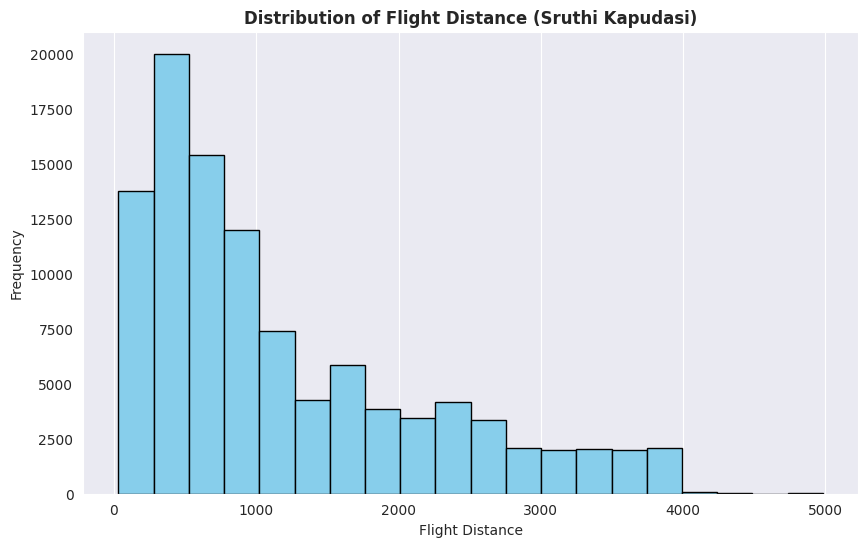

In [26]:
plt.figure(figsize=(10, 6))
plt.hist(df['FLIGHT_DISTANCE'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Flight Distance (Sruthi Kapudasi)', weight='bold')
plt.xlabel('Flight Distance')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

**Observations:**
- The distribution is skewed to the right, meaning there are fewer flights with longer distances. 
- This suggests that shorter flights are more common. 
- The peak of the distribution is between 0 and 1000 miles, indicating that the majority of flights fall within this range.

#### Bar Plots

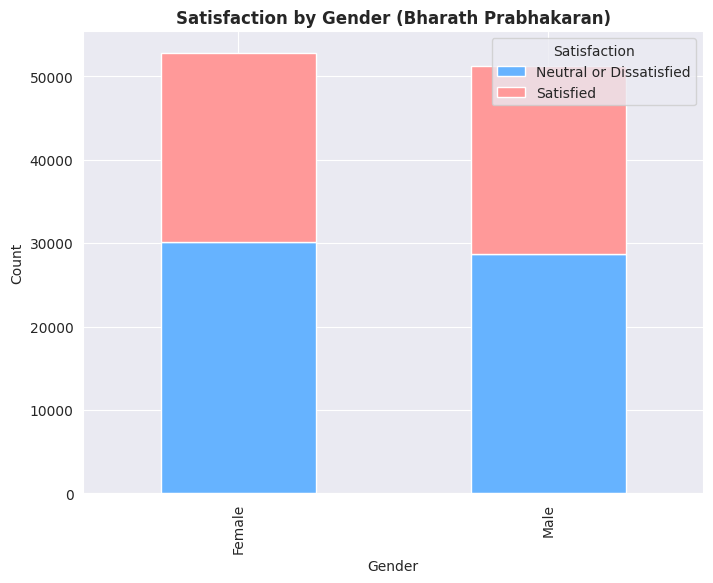

In [27]:
# Grouping data by GENDER and SATISFACTION to get the counts
gender_satisfaction = df.groupby(['GENDER', 'SATISFACTION']).size().unstack()

# Plotting a stacked bar chart for male vs female satisfaction
gender_satisfaction.plot(kind='bar', stacked=True, color=['#66b3ff','#ff9999'], figsize=(8,6))

plt.title('Satisfaction by Gender (Bharath Prabhakaran)', weight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Satisfaction')
plt.show()

The above stacked bar chart represents "Satisfaction by Gender" where, it  shows that both males and females have a similar distribution of satisfaction, with a larger proportion of customers falling into the "Neutral or Dissatisfied" category compared to "Satisfied." While dissatisfaction dominates for both genders, females appear to have a slightly higher satisfaction rate than males, though the difference is minimal. Overall, gender does not seem to have a significant impact on satisfaction levels.

#### Pie Charts

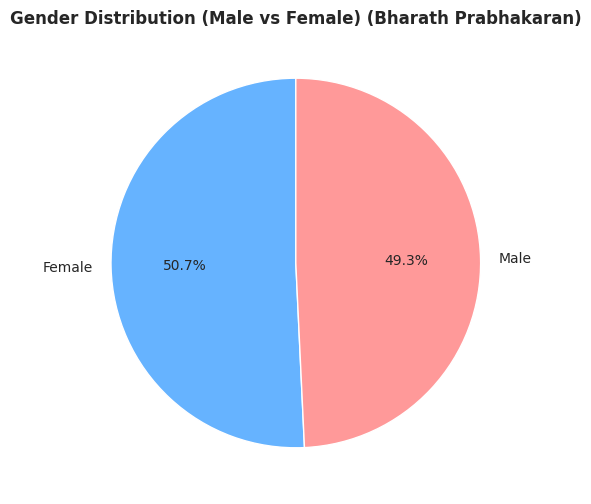

In [28]:
# Counting the number of males and females in the dataset
gender_counts = df['GENDER'].value_counts()

# Plotting the pie chart for male and female percentage
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Gender Distribution (Male vs Female) (Bharath Prabhakaran)', weight='bold')
plt.show()

The above pie chart displays the gender distribution in the dataset, with females slightly outnumbering males. Females make up 50.7% of the total, while males represent 49.3%. This indicates a nearly balanced gender split, ensuring that both genders are well-represented for analysis in the dataset.

#### Box Plots
https://seaborn.pydata.org/generated/seaborn.boxplot.html

In [29]:
def generate_boxplots(data: pd.DataFrame, ncols: int=4, figsize: tuple=(20, 15), **kwargs):
    """
    Generate box plot for dataset to determine outliers.

    Args:
        data (pd.DataFrame): Dataset to generate box plot for.
        ncols (int, optional): Number of column in the produced figure. Defaults to 4.
        figsize (tuple, optional): Size of the figure. Defaults to (20, 15).
    """
    if data is None or data.empty:
        return
    
    # Dynamically determine number of columns and rows for subplots
    ncols = min(ncols, len(data.columns))
    nrows = (len(data.columns) + ncols - 1) // ncols

    # Create subplots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    # Flatten 2D axes array to 1D
    if max(nrows, ncols) > 1:
        axes = axes.ravel()
    else:
        axes = np.array([axes])

    for i, col in enumerate(data.columns):
        sns.boxplot(data=data[col], ax=axes[i])
        axes[i].set_title(col)
        axes[i].set(xticklabels=[], xticks=[])

    # Remove unused plots
    for i in range(len(data.columns), nrows * ncols):
        fig.delaxes(axes[i])
    
    if 'title' in kwargs:
        fig.suptitle(kwargs.get('title'), weight='bold')
        
    plt.tight_layout()
    plt.show()

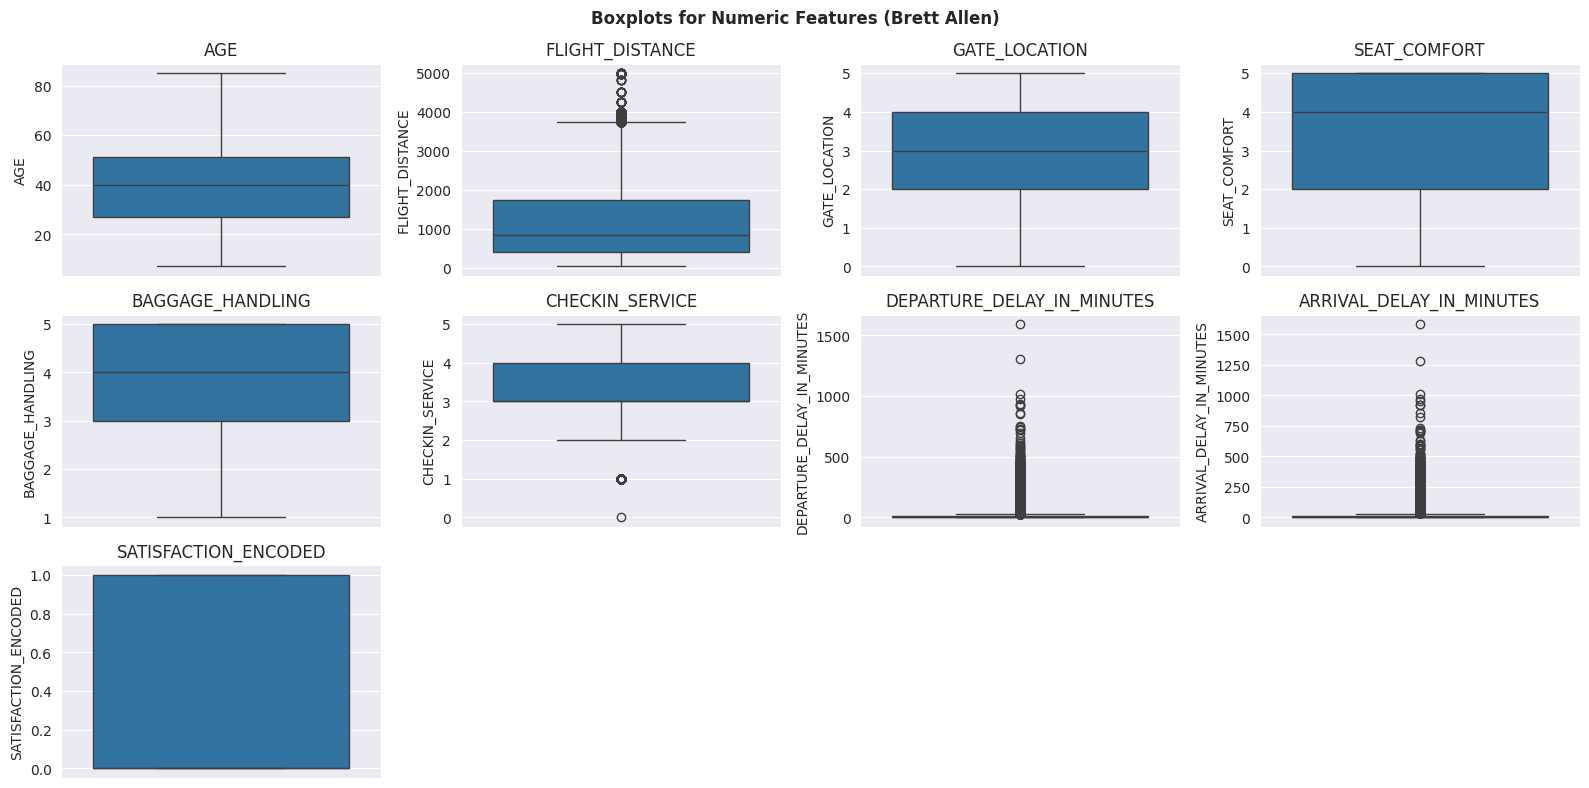

In [30]:
generate_boxplots(data=df.select_dtypes(include=['number']), figsize=(16, 8), title='Boxplots for Numeric Features (Brett Allen)')

Based on the boxplots, we can see that the majority of the numeric features do not have outliers. However, a few of the features do have outliers which will require further analysis to determine how to approach cleaning the data.
* `FLIGHT_DISTANCE`: The majority of the values fall between 500 and 1800, with the mean around 800. Any value greater than `~3800` appears to be an outlier.
* `CHECKIN_SERVICE`: The appears to only be a single or few outliers at a value of 1, with values ranging between 3 and 4. The outlier(s) is/are skewing the mean as it does not appear within the IQR box of the plot.
* `DEPARTURE_DELAY_IN_MINUTES`: There are a vast amount of outliers for this feature and it has a high priority for being cleaned. There are several outliers between the values 0 and ~20, with values greater than 1000 minutes, which is 16 hours!
* `ARRIVAL_DELAY_IN_MINUTES`: Similar to `DEPARTURE_DELAY_IN_MINUTES`, there are a lot of outliers that need to be resolved. The outliers appear to follow the exact pattern as `DEPARTURE_DELAY_IN_MINUTES`, where several outliers appear between 0 and ~20, with values greater than 1000 minutes (16 hours).

Checking values outside of $\pm$ 2 standard deviations should capture the outliers for each numeric feature respectively. Additional analysis such as interquartile range (IQR) should be done as well. We can resolve these outliers by applying transformations to the data such as `log transform` or `quantile transform`.

### Bivariate Analysis

#### Faceted Plots

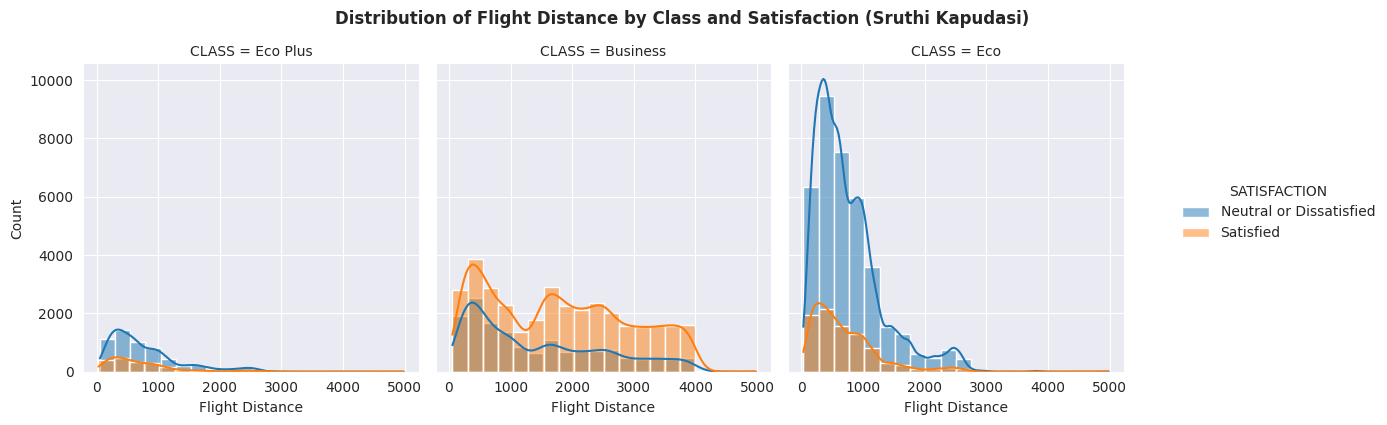

In [31]:
g = sns.FacetGrid(df, col='CLASS', hue='SATISFACTION', margin_titles=True, height=4)
g.map(sns.histplot, 'FLIGHT_DISTANCE', bins=20, kde=True)
g.add_legend()
g.set_axis_labels('Flight Distance', 'Count')
g.fig.suptitle('Distribution of Flight Distance by Class and Satisfaction (Sruthi Kapudasi)', y=1.05, weight='bold')
plt.show()

**Observations:**
- Flight distance varies by class and affects satisfaction.
- Business class: Shorter flights, higher satisfaction.
- Eco class: Longer flights, satisfaction linked to distance.
- Eco Plus class: Medium flights, satisfaction moderately linked to distance.

#### Count Plots

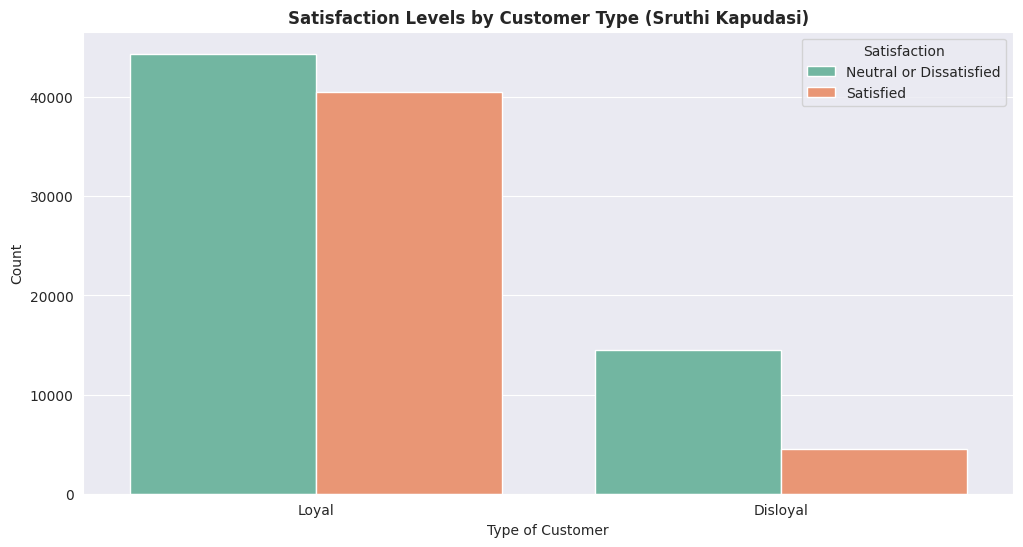

In [32]:
plt.figure(figsize=(12, 6))
sns.countplot(x='CUSTOMER_TYPE', hue='SATISFACTION', data=df, palette='Set2')
plt.title('Satisfaction Levels by Customer Type (Sruthi Kapudasi)', weight='bold')
plt.xlabel('Type of Customer')
plt.ylabel('Count')
plt.legend(title='Satisfaction')
plt.show()

**Observations:**
- Loyalty and Satisfaction: There's a strong correlation between customer loyalty and satisfaction. Loyal customers are significantly more likely to be satisfied than disloyal customers.
- Disloyal Customers: A larger proportion of disloyal customers are either neutral or dissatisfied. This suggests that dissatisfaction is a primary driver of customer churn.
- Loyal Customers: A significantly higher percentage of loyal customers are satisfied. This indicates that satisfied customers are more likely to remain loyal to the brand.

#### Violin Plots

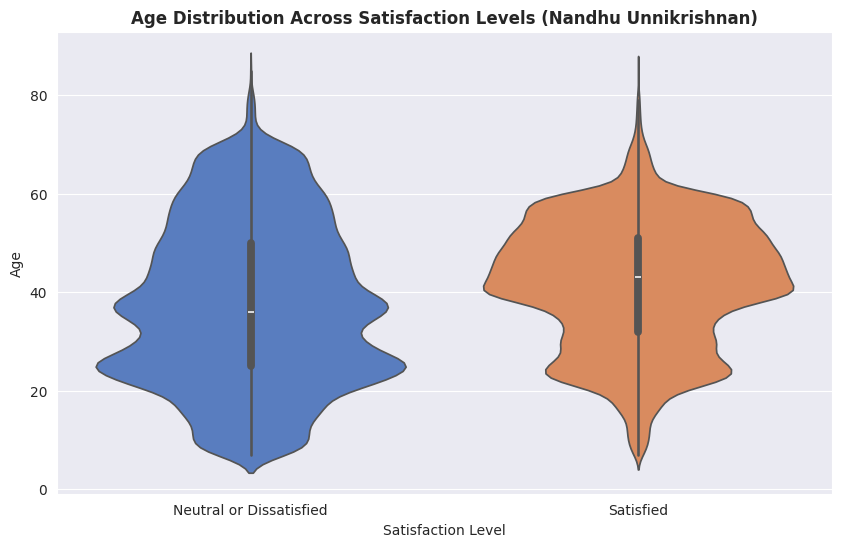

In [33]:
# Plot: Violin Plot for Age Distribution across Satisfaction Levels
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='SATISFACTION', y='AGE', palette='muted')
plt.title('Age Distribution Across Satisfaction Levels (Nandhu Unnikrishnan)', weight='bold')
plt.xlabel('Satisfaction Level')
plt.ylabel('Age')
plt.show()

**Insights:**
The violin plot helps visualize how different age groups rate their satisfaction. 
It shows whether certain age ranges are more likely to be satisfied or dissatisfied.

**Results:**
The violin plot reveals that satisfaction levels are fairly consistent across different 
age groups, with no extreme differences. However, younger passengers appear to have a 
slightly broader distribution, indicating more variability in their satisfaction compared 
to older passengers, who tend to cluster around specific satisfaction levels.

#### Scatter Plots

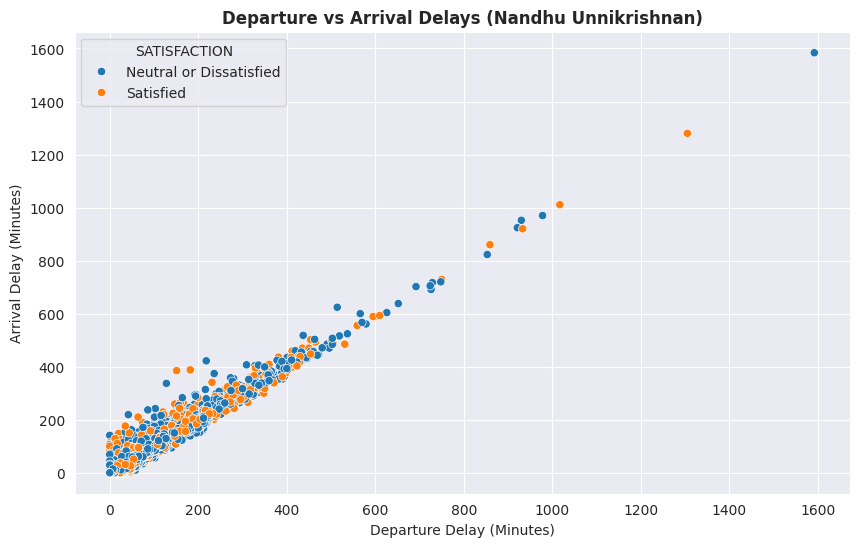

In [34]:
# Plot: Scatter Plot of Departure Delay vs Arrival Delay
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='DEPARTURE_DELAY_IN_MINUTES', y='ARRIVAL_DELAY_IN_MINUTES', hue='SATISFACTION')
plt.title('Departure vs Arrival Delays (Nandhu Unnikrishnan)', weight='bold')
plt.xlabel('Departure Delay (Minutes)')
plt.ylabel('Arrival Delay (Minutes)')
plt.show()

**Insights:**
This scatter plot shows the relationship between delays at departure and arrival, 
categorized by satisfaction levels. If longer delays consistently lead to dissatisfaction, 
this insight can help airlines focus on improving timeliness to boost customer satisfaction.

**Results:**
The scatter plot shows a clear relationship between departure and arrival delays, as expected. 
Longer departure delays often result in longer arrival delays. Passengers experiencing significant 
delays at both departure and arrival points tend to be more dissatisfied, confirming the importance 
of minimizing delays to maintain satisfaction.

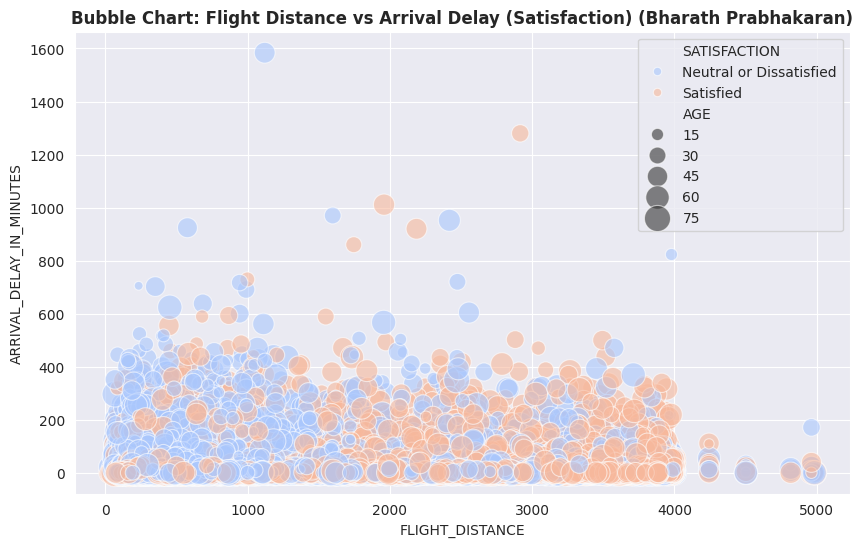

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FLIGHT_DISTANCE', y='ARRIVAL_DELAY_IN_MINUTES',
                size='AGE', hue='SATISFACTION', palette='coolwarm', sizes=(40, 400), alpha=0.6)
plt.title('Bubble Chart: Flight Distance vs Arrival Delay (Satisfaction) (Bharath Prabhakaran)', weight='bold')
plt.show()

This bubble chart shows that there's no strong correlation between flight distance, arrival delay, and passenger satisfaction. While longer flights and greater delays generally lead to more dissatisfaction, there are numerous exceptions.  Age doesn't appear to be a major factor in satisfaction levels, though younger passengers seem slightly more tolerant of delays on shorter flights.  Interestingly, some of the longest flights with significant delays still have satisfied customers, suggesting other factors like service quality might play a more significant role in overall satisfaction.

#### Regression Plots
https://seaborn.pydata.org/generated/seaborn.regplot.html

In [36]:
def generate_regplots(data: pd.DataFrame, comparator_col: str, ncols: int=4, figsize: tuple=(20, 15), transformer: Any=None, title: str=None, **kwargs):
    """
    Generate regression (reg) plot for dataset to determine outliers.

    Args:
        data (pd.DataFrame): Dataset to generate reg plot for.
        comparator_col (str): Column to compare other columns to for bivariate analysis.
        ncols (int, optional): Number of column in the produced figure. Defaults to 4.
        figsize (tuple, optional): Size of the figure. Defaults to (20, 15).
        transformer (Any, optional): Sklearn transformer instance to apply transform to data.
        title (str, optional): Title of the main plot. Defaults to None and no title is displayed.
    """
    if data is None or data.empty:
        return

    # Create copy of the data to prevent mutations to original
    _data = data.copy(deep=True)

    # Apply transform to data
    if transformer is not None:
        _data = transformer.fit_transform(_data)
    
    # Dynamically determine number of columns and rows for subplots
    cols = data.columns.tolist()
    comparator_col_idx = cols.index(comparator_col)
    ncols = min(ncols, len(cols))
    nrows = (len(cols) + ncols - 1) // ncols

    # Create subplots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    # Flatten 2D axes array to 1D
    if max(nrows, ncols) > 1:
        axes = axes.ravel()
    else:
        axes = np.array([axes])

    # Iterate columns except for comparator column to prevent comparing to itself
    analysis_cols = [col for col in cols if col != comparator_col]
    for i, col in enumerate(analysis_cols):
        x = _data[comparator_col] if isinstance(_data, pd.DataFrame) else _data[comparator_col_idx]
        y = _data[col] if isinstance(_data, pd.DataFrame) else _data[i]
        sns.regplot(x=x, y=y, ax=axes[i], **kwargs)
        axes[i].set_title(f'{comparator_col} and {col}', fontsize=9)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

    # Remove unused plots
    for i in range(len(analysis_cols), nrows * ncols):
        fig.delaxes(axes[i])
    
    if title:
        fig.suptitle(title, weight='bold')
        
    plt.tight_layout(pad=2.0)
    # plt.subplots_adjust(top=0.91)
    plt.show()

In [37]:
# Only target numeric columns for regression plots
target_reg_cols = df.select_dtypes(include=['number']).columns.tolist()
target_reg_cols

['AGE',
 'FLIGHT_DISTANCE',
 'GATE_LOCATION',
 'SEAT_COMFORT',
 'BAGGAGE_HANDLING',
 'CHECKIN_SERVICE',
 'DEPARTURE_DELAY_IN_MINUTES',
 'ARRIVAL_DELAY_IN_MINUTES',
 'SATISFACTION_ENCODED']

In [38]:
# Add columns that have 'Not Applicable' string for 0 values
target_reg_cols = list(set(target_reg_cols + ['INFLIGHT_WIFI_SERVICE', 'DEPARTURE_ARRIVAL_TIME_CONVENIENT', 'EASE_OF_ONLINE_BOOKING', 'FOOD_AND_DRINK', 'ONLINE_BOARDING', 'ON-BOARD_SERVICE', 'INFLIGHT_ENTERTAINMENT', 'LEG_ROOM_SERVICE', 'INFLIGHT_SERVICE', 'CLEANLINESS']))
target_reg_cols

['INFLIGHT_WIFI_SERVICE',
 'AGE',
 'EASE_OF_ONLINE_BOOKING',
 'DEPARTURE_ARRIVAL_TIME_CONVENIENT',
 'CHECKIN_SERVICE',
 'CLEANLINESS',
 'INFLIGHT_ENTERTAINMENT',
 'FOOD_AND_DRINK',
 'LEG_ROOM_SERVICE',
 'ONLINE_BOARDING',
 'INFLIGHT_SERVICE',
 'ARRIVAL_DELAY_IN_MINUTES',
 'DEPARTURE_DELAY_IN_MINUTES',
 'ON-BOARD_SERVICE',
 'FLIGHT_DISTANCE',
 'BAGGAGE_HANDLING',
 'GATE_LOCATION',
 'SEAT_COMFORT',
 'SATISFACTION_ENCODED']

In [39]:
# Coerce conversion from string to numeric (replace text with NaN)
for col in target_reg_cols:
    dtype = df[col].dtype
    if dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')

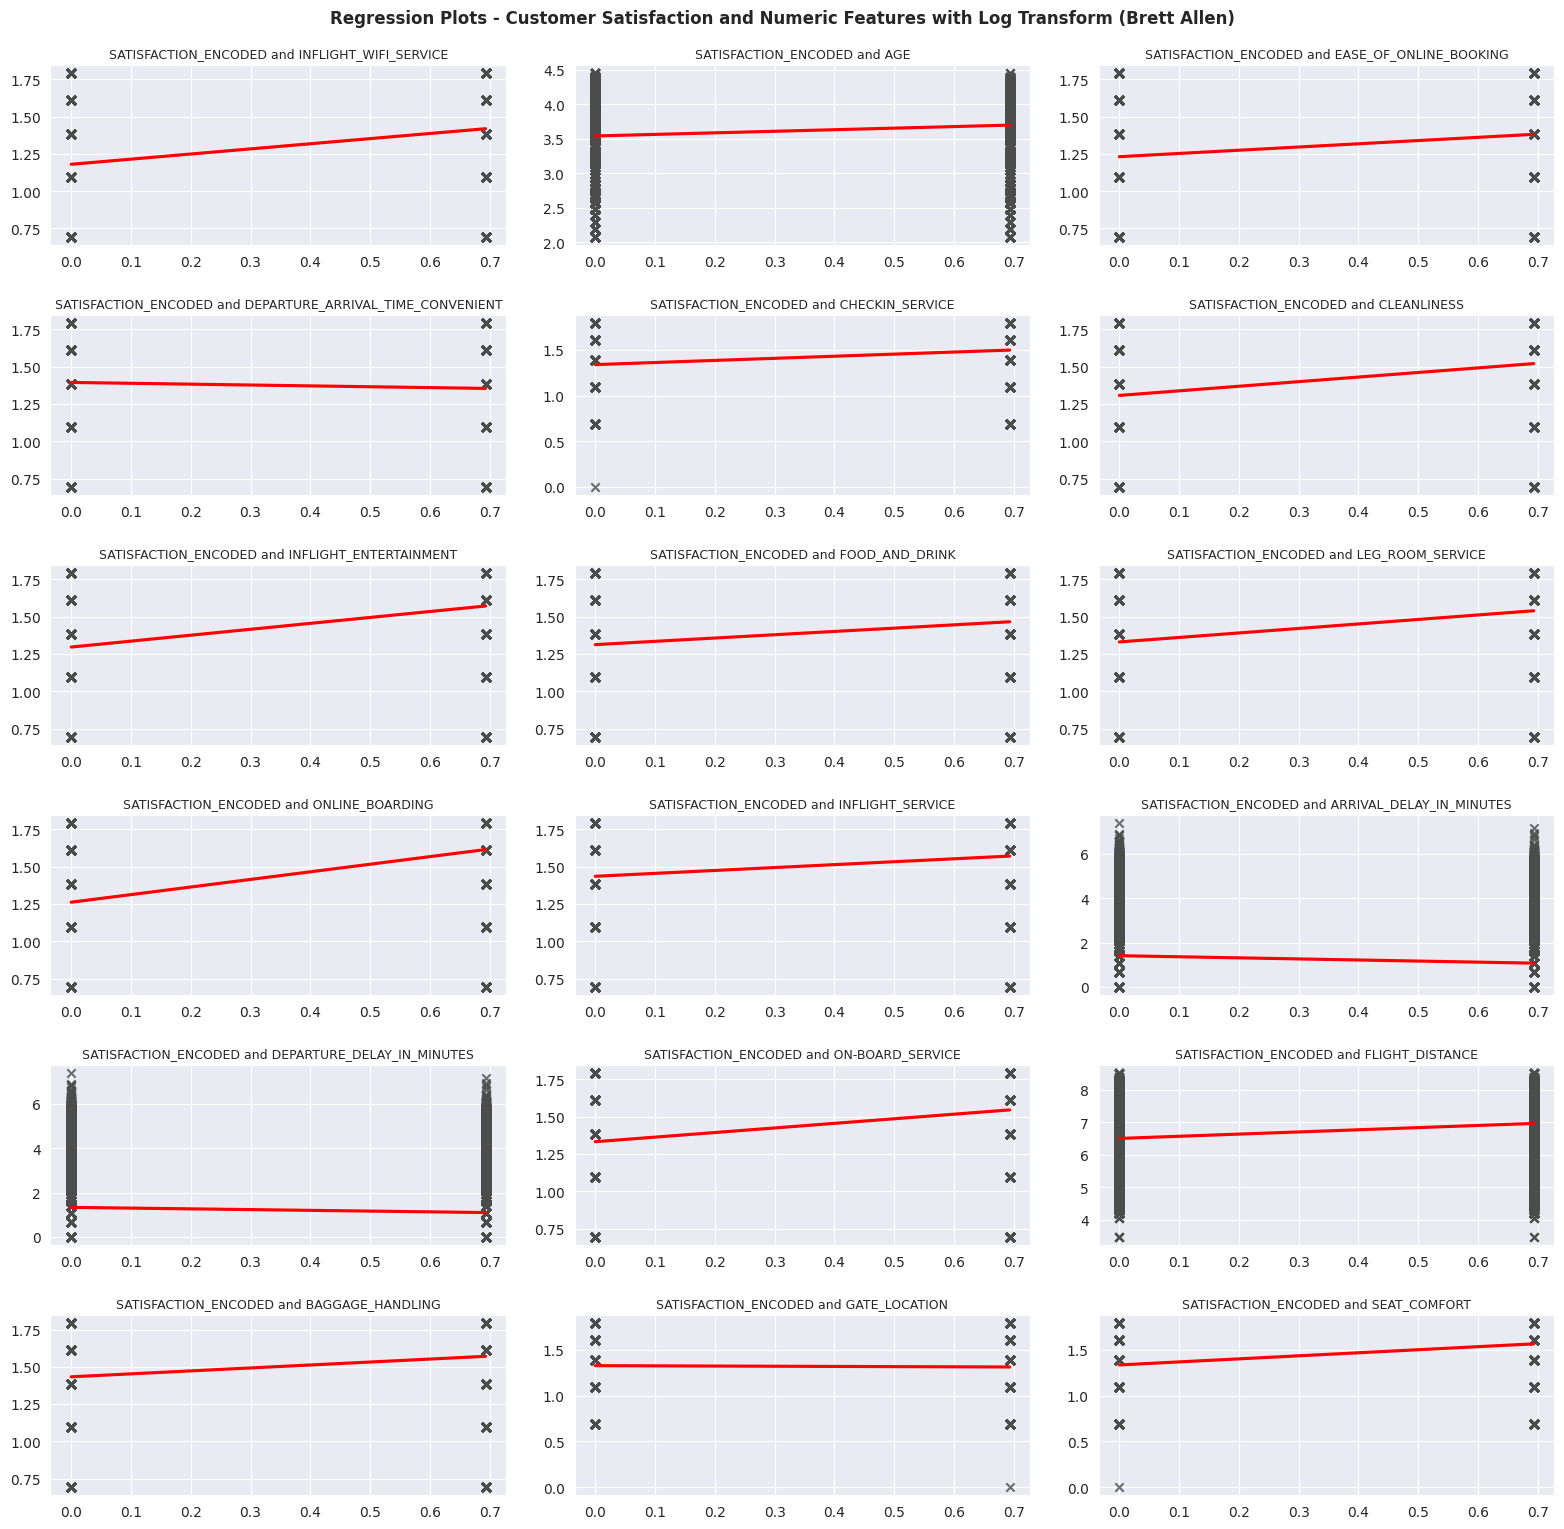

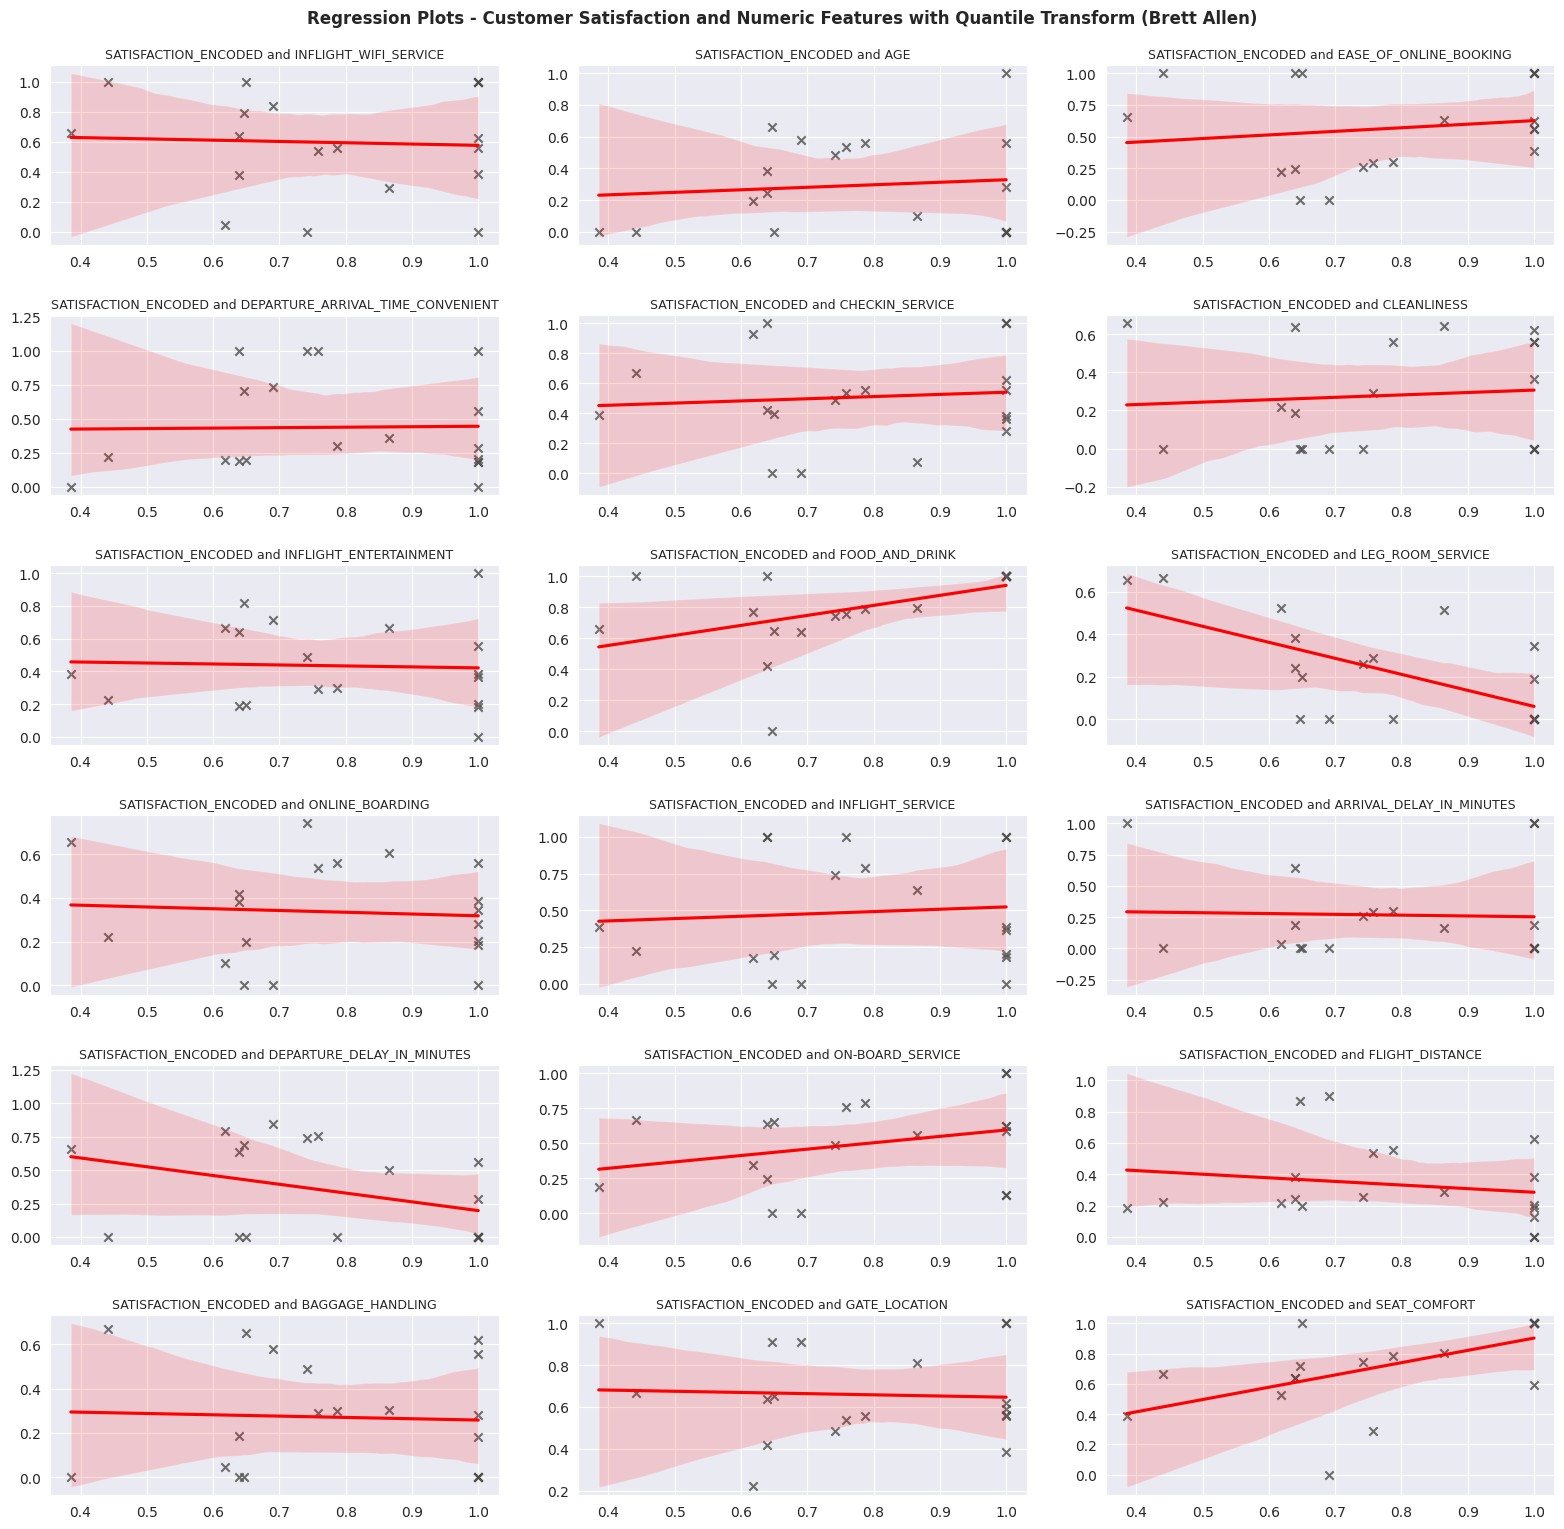

In [40]:
# Create transformer instances
func_transformer = FunctionTransformer(np.log1p)
quant_transformer = QuantileTransformer()
figsize = (16, 18)

# Generate the regression plots
generate_regplots(
    df[target_reg_cols],
    comparator_col='SATISFACTION_ENCODED',
    ncols=3,
    figsize=figsize,
    transformer=func_transformer,
    ci=99,
    marker='x',
    color='.3',
    line_kws=dict(color='r'),
    title='Regression Plots - Customer Satisfaction and Numeric Features with Log Transform (Brett Allen)'
)

generate_regplots(
    df[target_reg_cols],
    comparator_col='SATISFACTION_ENCODED',
    ncols=3,
    figsize=figsize,
    transformer=quant_transformer,
    ci=99,
    marker='x',
    color='.3',
    line_kws=dict(color='r'),
    title='Regression Plots - Customer Satisfaction and Numeric Features with Quantile Transform (Brett Allen)'
)

We can observe that applying log transform to the numeric features does not provide iterpretable insights as much as applying quantile transform does. Thus, observing the results after applying quantile transform, we can see that there are **positive linear correlations** between **customer satisfaction** and the following features:
1) `FLIGHT_DISTANCE`
2) `INFLIGHT_WIFI_SERVICE`
3) `DEPARTURE_ARRIVAL_TIME_CONVENIENT` (nearly neutral)
4) `EASE_OF_ONLINE_BOOKING`
5) `GATE_LOCATION`
6) `FOOD_AND_DRINK` (nearly neutral)
7) `ONLINE_BOARDING`
8) `ON-BOARD_SERVICE`
9) `CHECKIN_SERVICE`
10) `ARRIVAL_DELAY_IN_MINUTES`

Conversely, there is a **negative linear correlation** between **customer satisfaction** and the following features:
1) `AGE`
2) `SEAT_COMFORT`
3) `INFLIGHT_ENTERTAINMENT` (nearly neutral)
4) `LEG_ROOM_SERVICE` (nearly neutral)
5) `BAGGAGE_HANDLING`
6) `INFLIGHT_SERVICE`
7) `CLEANLINESS` (nearly neutral)
8) `DEPARTURE_DELAY_IN_MINUTES`


### Multivariate Analysis

#### Heatmap Plots

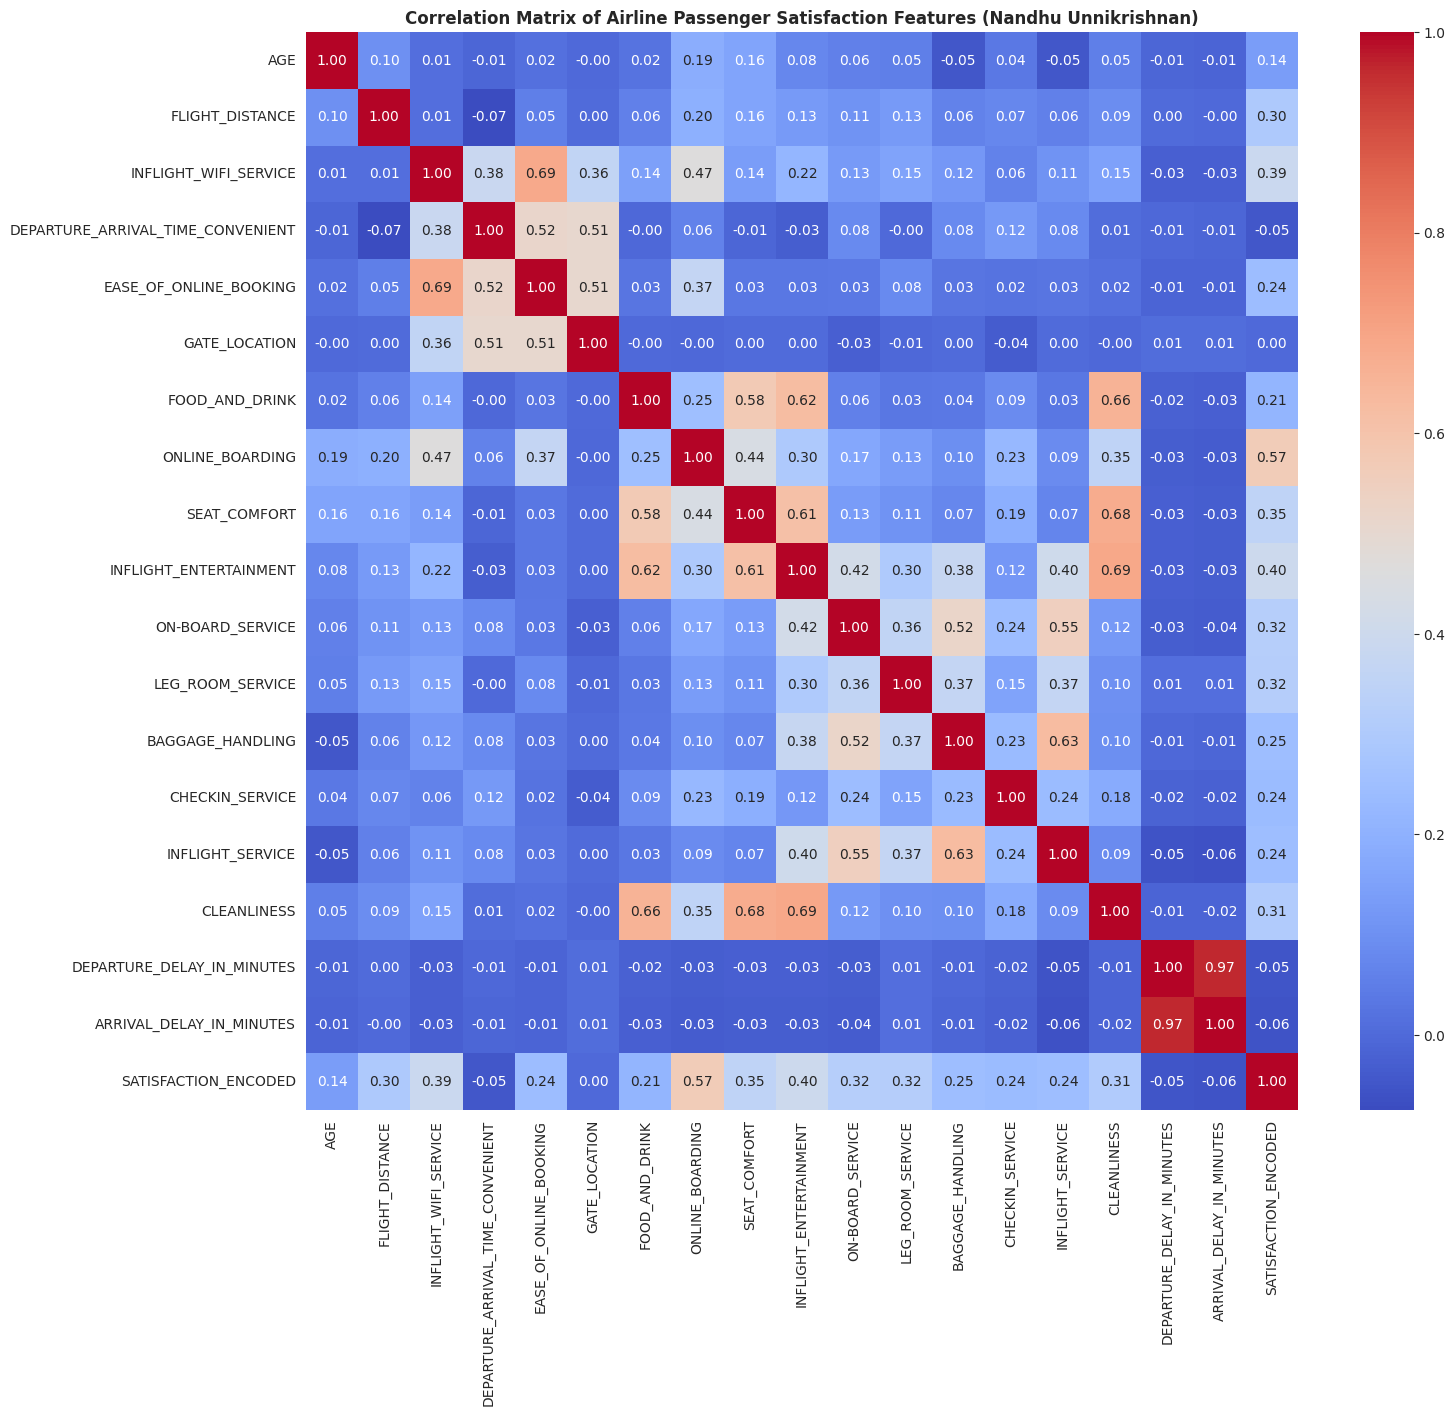

In [41]:
# Select only numeric columns for the correlation matrix
numeric_data = df.select_dtypes(include=['float64', 'int64'])

# Plot: Correlation Matrix for relevant features
plt.figure(figsize=(16, 14))
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Airline Passenger Satisfaction Features (Nandhu Unnikrishnan)', weight='bold')
plt.show()

**Insights:**
This matrix shows how different numerical features relate to each other. 
For example, it can highlight whether inflight service ratings are strongly 
linked to overall satisfaction. This helps us identify which factors may be 
the most influential in predicting passenger satisfaction and can guide feature 
selection for model building.

**Results:**
The correlation matrix shows that inflight service features, such as inflight wifi, 
entertainment, and overall service, have a positive correlation with passenger satisfaction. 
However, factors like flight delays have weaker correlations with satisfaction. This suggests 
that while amenities onboard contribute significantly to satisfaction, operational factors 
like delays might have a less direct impact.

#### Pair Plots
https://seaborn.pydata.org/generated/seaborn.pairplot.html

In [42]:
def generate_pairplot(data: pd.DataFrame, legend_loc: str='upper left', legend_ncol: int=1, title: str='Pairwise Plots', **kwargs):
    """
    Generate pair plot for all numeric columns in the provided dataset.
    For enhanced visualization/eda, pass in "hue" keyword argument with
    a categorical column (column with unique and finite set of values).

    Args:
        data (pd.DataFrame): Dataset to create pair plot for.
        legend_loc (str, optional): Location to render the legend if hue is provided (e.g., "upper left", "lower center", etc.). Honored if "hue" kwarg is provided. Default "upper left".
        legend_ncol (int, optional): Number of columns in legend to control whether items in legend are displayed horizontally vs. vertically. Honored if "hue" kwarg is provided. Default 1.
        title (str, optional): Title to display. Default None and will not be displayed.
    """
    numeric_cols = list(data.select_dtypes('number'))
    g = sns.pairplot(data[numeric_cols], **kwargs)

    # Place legend in different location as desired
    # Inspired by https://stackoverflow.com/a/40910102
    if kwargs.get('hue'):
        handles = g._legend_data.values()
        labels = g._legend_data.keys()
        sns.move_legend(g, legend_loc, labels=labels, ncol=legend_ncol, title=kwargs.get('hue'), frameon=False)
        g.figure.subplots_adjust(top=0.92, bottom=0.08)

    plt.suptitle(title, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

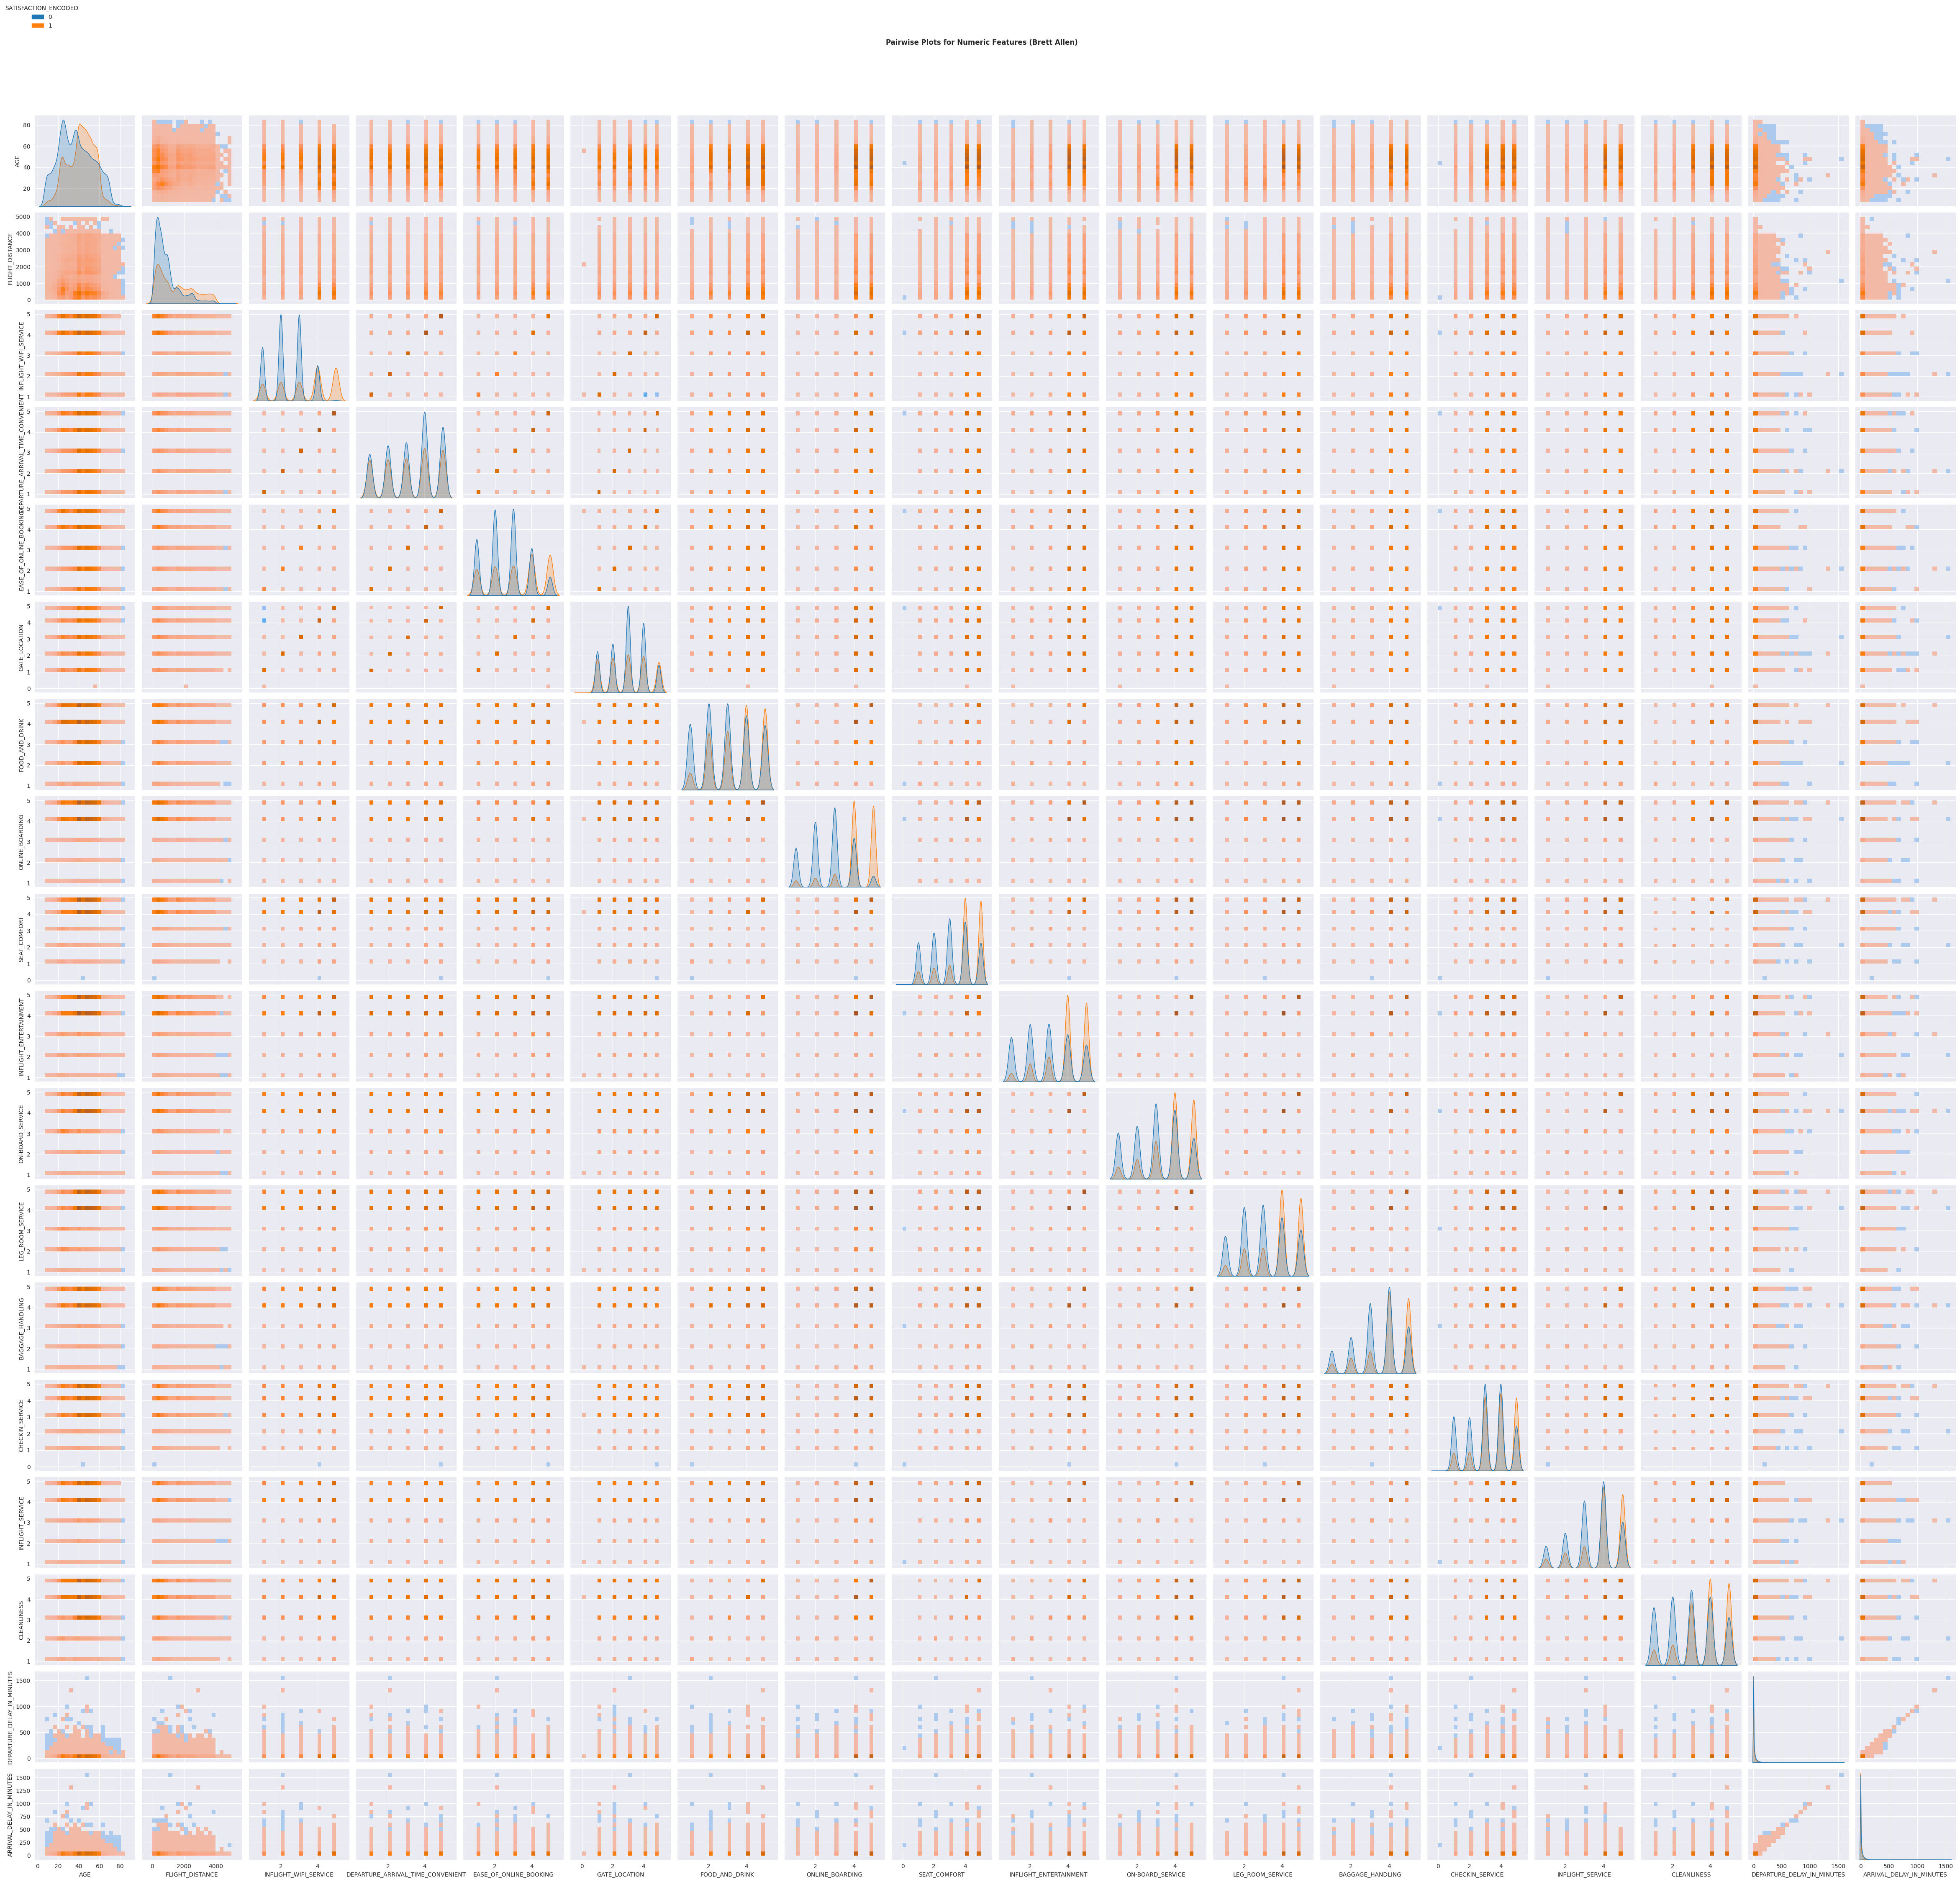

In [44]:
generate_pairplot(
    df, 
    hue='SATISFACTION_ENCODED', 
    title='Pairwise Plots for Numeric Features (Brett Allen)', 
    kind='hist', 
    diag_kind='kde', 
    plot_kws={ 'bins': 20 }
)

In [45]:
# Analyze variance
df.select_dtypes(include='number').var()

AGE                                     228.462128
FLIGHT_DISTANCE                      994302.699066
INFLIGHT_WIFI_SERVICE                     1.580971
DEPARTURE_ARRIVAL_TIME_CONVENIENT         1.920414
EASE_OF_ONLINE_BOOKING                    1.686810
GATE_LOCATION                             1.632315
FOOD_AND_DRINK                            1.758898
ONLINE_BOARDING                           1.605913
SEAT_COMFORT                              1.739992
INFLIGHT_ENTERTAINMENT                    1.775584
ON-BOARD_SERVICE                          1.659575
LEG_ROOM_SERVICE                          1.687235
BAGGAGE_HANDLING                          1.394533
CHECKIN_SERVICE                           1.601227
INFLIGHT_SERVICE                          1.381841
CLEANLINESS                               1.721011
DEPARTURE_DELAY_IN_MINUTES             1461.601759
ARRIVAL_DELAY_IN_MINUTES               1497.587990
SATISFACTION_ENCODED                      0.245558
dtype: float64

We can see based on the pairwise plots and variance analysis that there are features with low variance (e.g., categorical) which do not provide much value when analyzing with pairwise plots:
```
INFLIGHT_WIFI_SERVICE                     1.580971
DEPARTURE_ARRIVAL_TIME_CONVENIENT         1.920414
EASE_OF_ONLINE_BOOKING                    1.686810
GATE_LOCATION                             1.632315
FOOD_AND_DRINK                            1.758898
ONLINE_BOARDING                           1.605913
SEAT_COMFORT                              1.739992
INFLIGHT_ENTERTAINMENT                    1.775584
ON-BOARD_SERVICE                          1.659575
LEG_ROOM_SERVICE                          1.687235
BAGGAGE_HANDLING                          1.394533
CHECKIN_SERVICE                           1.601227
INFLIGHT_SERVICE                          1.381841
CLEANLINESS                               1.721011
```
We can produce a much cleaner pairwise plot visualization by exlcuding the categorical features with low variance and only targeting the high variance features.

In [46]:
# Generate version of pairplot with features that have variance greater than 2
numeric_cols_variances = df.select_dtypes(include='number').var()
high_variance_cols = numeric_cols_variances[numeric_cols_variances > 2].index.tolist()
if 'SATISFACTION_ENCODED' not in high_variance_cols:
    high_variance_cols.append('SATISFACTION_ENCODED')
high_variance_cols

['AGE',
 'FLIGHT_DISTANCE',
 'DEPARTURE_DELAY_IN_MINUTES',
 'ARRIVAL_DELAY_IN_MINUTES',
 'SATISFACTION_ENCODED']

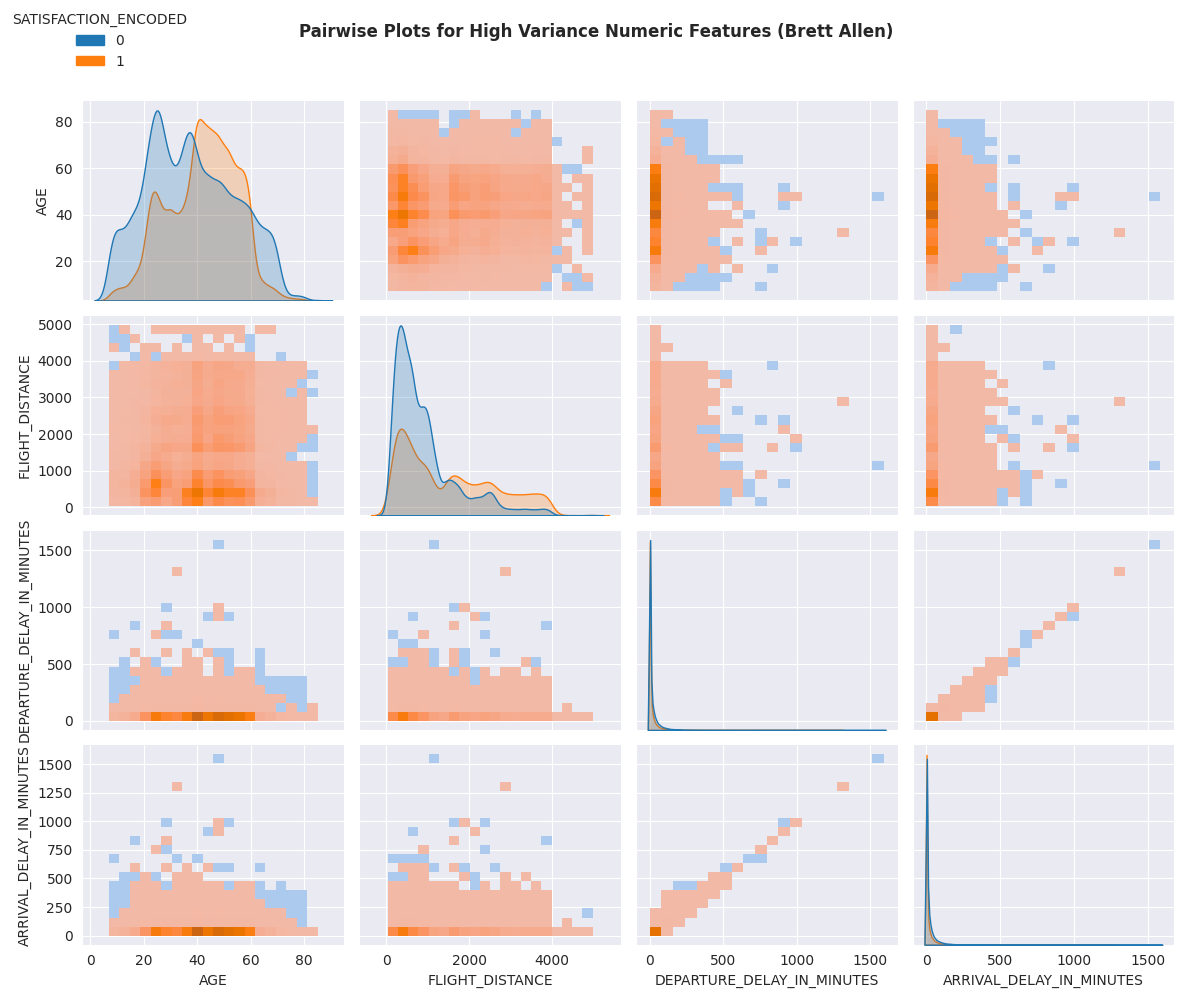

In [47]:
generate_pairplot(
    df[high_variance_cols], 
    hue='SATISFACTION_ENCODED', 
    title='Pairwise Plots for High Variance Numeric Features (Brett Allen)',
    kind='hist', 
    diag_kind='kde', 
    plot_kws={ 'bins': 20 }
)

Now the pairwise plot looks much cleaner as we are only analyzing high variance features. Based on the pairwise plot, there appears to be a strong positive linear correlation between `ARRIVAL_DELAY_IN_MINUTES` and `DEPARTURE_DELAY_IN_MINUTES`. There is a slight linear correlation between `FLIGHT_DISTANCE` and `ARRIVAL_DELAY_IN_MINUTES` as well as `FLIGHT_DISTANCE` and `ARRIVAL_DELAY_IN_MINUTES`. Similarily with `AGE` and `FLIGHT_DISTANCE`, `ARRIVAL_DELAY_IN_MINUTES`, and `DEPARTURE_DELAY_IN_MINUTES`